In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

In [6]:
load_dotenv() # Load environment variables from .env file

True

In [7]:
LLM = ChatGroq(model = "openai/gpt-oss-120b", temperature = 0.7)

In [8]:
# state
class blogllm(TypedDict):
    title: str
    outline: str
    content: str

In [9]:
def topic_generatorllm(state: blogllm) -> blogllm:
    # taking the topic state
    title = state['title']
    
    prompt = f"give me a outline around this title: {title}"
    
    outline = LLM.invoke(prompt).content
    
    state['outline'] = outline
    
    return state
    

In [10]:
def blog_generatorllm(state: blogllm) -> blogllm:
    # taking the outline from state
    outline = state['outline']
    
    prompt = f"write a detailed blog around this outline: {outline}"
    
    content = LLM.invoke(prompt).content
    
    state['content'] = content
    
    return state

In [11]:
# graph
graph = StateGraph(blogllm)

# nodes
graph.add_node("topic_generation", topic_generatorllm)
graph.add_node("blog_generation", blog_generatorllm)

# edges
graph.add_edge(START, "topic_generation")
graph.add_edge("topic_generation", "blog_generation")
graph.add_edge("blog_generation", END)

# compile
workflow = graph.compile()


In [12]:
# execution
initial_state = {"title": "The Future of Artificial Intelligence: Trends and Predictions"}

output_state = workflow.invoke(initial_state)


In [14]:
print("Title:", output_state['title'])

Title: The Future of Artificial Intelligence: Trends and Predictions


In [15]:
print("Outline:", output_state['outline'])

Outline: **Outline: “The Future of Artificial Intelligence: Trends and Predictions”**

---

### I. Introduction  
1. **Hook** – A striking statistic or anecdote illustrating AI’s rapid growth (e.g., “In 2024, AI‑generated content accounted for over 30 % of online media”).  
2. **Why the Future of AI Matters** – Economic, societal, and geopolitical implications.  
3. **Scope & Methodology** – Brief note on sources (industry reports, academic research, expert interviews) and the time horizon (2025‑2045).

---

### II. Current State of AI (2020‑2024)  
1. **Technological Foundations**  
   - Deep learning breakthroughs (transformers, diffusion models).  
   - Advances in reinforcement learning, multimodal models, and neuromorphic hardware.  
2. **Deployment Landscape**  
   - Enterprise AI (automation, analytics, decision support).  
   - Consumer AI (virtual assistants, generative media, personalized recommendation).  
3. **Regulatory & Ethical Baseline**  
   - Existing frameworks (EU A

In [16]:
print("content", output_state['content'])

content **The Future of Artificial Intelligence: Trends and Predictions**  
*From the foundations we built in 2020‑2024 to the world we’ll inhabit in 2045*  

---

## I. Introduction  

### 1. Hook – A Snapshot of AI’s Explosive Growth  

> **“In 2024, AI‑generated content accounted for more than 30 % of all media consumed online, and the number of AI‑powered products on the market doubled every 18 months.”**  

That single statistic tells a story that is hard to ignore: the tools that once lived in research labs are now shaping the news we read, the music we stream, and the decisions we make at work.  

### 2. Why the Future of AI Matters  

Artificial intelligence is no longer a niche technology; it is a **strategic asset** that influences every major dimension of modern life:

| Dimension | Why It Counts |
|-----------|---------------|
| **Economic** | AI is projected to add **$15 trillion** to global GDP by 2030, reshaping productivity, new market creation, and the competitive land

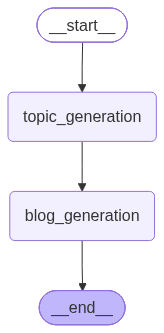

In [13]:
# visualization
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())